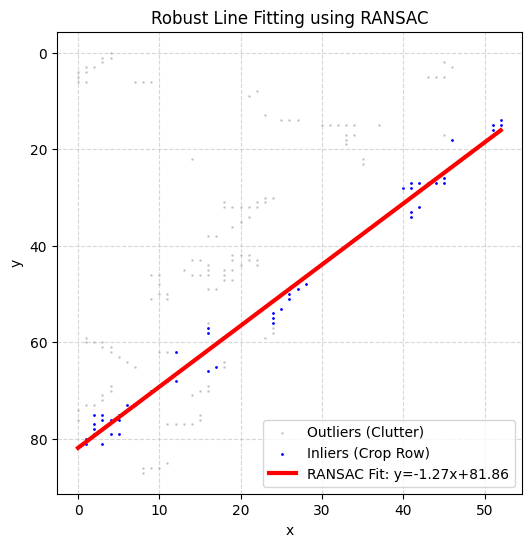

RANSAC Estimated Slope (m): -1.2652602183537214
RANSAC Estimated Intercept (b): 81.8553180234747


In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

img = cv.imread('img.jpg', cv.IMREAD_GRAYSCALE)

if img is not None:
    edges = cv.Canny(img, 550, 690)
    indices = np.where(edges != 0)
    x = indices[1]
    y = indices[0]

    X = x.reshape(-1, 1)

    ransac = RANSACRegressor(residual_threshold=5.0, random_state=42)
    ransac.fit(X, y)

    m_robust = ransac.estimator_.coef_[0]
    b_robust = ransac.estimator_.intercept_

    x_fit = np.array([np.min(x), np.max(x)])
    y_fit = m_robust * x_fit + b_robust

    inlier_mask = ransac.inlier_mask_
    outlier_mask = np.logical_not(inlier_mask)

    plt.figure(figsize=(6, 6))

    plt.scatter(x[outlier_mask], y[outlier_mask], s=1, c='gray', alpha=0.3, label='Outliers (Clutter)')
    plt.scatter(x[inlier_mask], y[inlier_mask], s=1, c='blue', label='Inliers (Crop Row)')

    plt.plot(x_fit, y_fit, color='red', linewidth=3, label=f'RANSAC Fit: y={m_robust:.2f}x+{b_robust:.2f}')

    plt.gca().invert_yaxis()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Robust Line Fitting using RANSAC')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print(f"RANSAC Estimated Slope (m): {m_robust}")
    print(f"RANSAC Estimated Intercept (b): {b_robust}")
else:
    print("Error: Image not found.")